<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/float-api/float-api-example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let's start with installing the `sec-api` Python package.

In [1]:
!pip -q install sec-api

Initialize the `FloatApi` with your API key so that your requests are automatically authenticated.

In [2]:
from sec_api import FloatApi
import pandas as pd

floatApi = FloatApi('YOUR_API_KEY')

Next, we use the `.get_float()` method to fetch all historical float data for Google using the `ticker` search functionality. Looking up float information by CIK is supported as well.

The response of the Float API represents an object with all keys described in the [documentation here](https://sec-api.io/docs/outstanding-shares-float-api#response-structure). For this example, we are interested in the `float.oustandingShares` list and the `reportedAt` field.

In [3]:
response = floatApi.get_float(ticker='GOOG') # AAPL
# alternative: use cik lookup 
# response = floatApi.get_float(cik='320193')

All historical float information is included in the `data` list of the `response` object. `pd.json_normalize()` helps us converting the JSON data of the response into a pandas DataFrame. 

In [4]:
df = pd.json_normalize(response['data'])
# convert reportedAt strings into pandas datetime objects 
# to help us to print along the reportedAt time axis
df['reportedAt'] = pd.to_datetime(df['reportedAt'])
df.drop(columns=['id'], inplace=True) # 'tickers', 'cik'
df.head(3)

,tickers,cik,reportedAt,periodOfReport,sourceFilingAccessionNo,float.outstandingShares,float.publicFloat
0,"[GOOGL, GOOG]",1652044,2023-02-02 21:23:45-05:00,2022-12-31,0001652044-23-000016,"[{'period': '2023-01-26', 'shareClass': 'Commo...","[{'period': '2022-06-30', 'shareClass': '', 'v..."
1,"[GOOGL, GOOG]",1652044,2022-10-25 21:32:59-04:00,2022-09-30,0001652044-22-000090,"[{'period': '2022-10-18', 'shareClass': 'Commo...",[]
2,"[GOOGL, GOOG]",1652044,2022-07-26 19:29:36-04:00,2022-06-30,0001652044-22-000071,"[{'period': '2022-07-22', 'shareClass': 'Commo...",[]


In [5]:
print('Datatypes:')
print('Cells of `float.outstandingShares` column:\t\t', type(df['float.outstandingShares'][0]))
print('Item of a list in a cell of float.outstandingShares:\t', type(df['float.outstandingShares'][0][0]))

Datatypes:
Cells of `float.outstandingShares` column:		 <class 'list'>
Item of a list in a cell of float.outstandingShares:	 <class 'dict'>


<!-- As we can see, the `float.outstandingShares` and `float.publicFloat` columns include lists of dictionaries instead of scalars (strings or integers).  -->

--- 

Note: If you are already familiar with pandas' `.explode()` function, you can skip ahead to the next section.

As we can see, each cell of the `float.outstandingShares` column includes a list of three dictionaries instead of single scalars (strings and integers). The reason being is that each cell represents a moment in time where the information about the float of each share class was disclosed. In case of Google's outstanding shares, we deal with three different share classes: 

- Common Class A 
- Common Class B
- Capital Class C

For that reason, a cell always includes a list with at least one dictionary (representing one share class), while the list can include more than one dictionary if more than one share class is available.

Our goal is to unnest (or explode) each cell so that we can access the `period`, `shareClass` and `value` per `shareClass` individually via separate columns instead of having to destruct all the dictionaries every time we want to access the information for a specific share class.

In the following step we split the `float.outstandingShares` column into three new columns, `period`, `shareClass` and `value` (=number of shares outstanding per share class) and unnest all dictnaries per list. The same will be done for the `float.publicFloat` column so that we end up with six new columns in total. The [`.explode()` method in pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html) helps us here.

We split the `float.outstandingShares` column by creating a new column for each key of the dictionaries. For example, the first cell represents a list of three dictionaries with three key/value pairs:

 ```python
 [
  {'period': '2023-01-26', 'shareClass': 'CommonClassA', 'value': 5956000000},
  {'period': '2023-01-26', 'shareClass': 'CommonClassB', 'value': 883000000},
  {'period': '2023-01-26', 'shareClass': 'CapitalClassC', 'value': 5968000000}
 ]
 ``` 

With the keys: `period`, `shareClass`, `value`.

First, we run `df.explode('float.outstandingShares')` to turn a single row into as many new rows as there are dictionaries in the list of the `float.outstandingShares` cell of the row.

Next, we convert each dictionary per row into a one-dimensional array (series) with three values, each value representing the `period`, `shareClass` and `value` values. The corresponding function is: `df['float.outstandingShares'].apply(pd.Series)`

<!-- converting the key/value pairs of all dictionaries `{key: value}` into a separate column of strings and integers.  -->

The entire conversion is depicted in the figure below.


![img](https://i.imgur.com/5fAyOzbl.png)

<!-- ![img](https://i.imgur.com/0zF5aA3l.png) -->

<!-- ![img](https://i.imgur.com/m1kixxrl.png) -->

The first snippet of our `df` dataframe represents the first two rows of the `float.outstandingShares` column. Each row includes three dictionaries, each dictionary includes three key/values pairs, highlighted in red, blue and yellow, respectively. After the conversion, the resulting new dataframe has three columns, and six rows. In other words, the first cell of the `float.outstandingShares` column was split into three new rows and three new columns.

In the final step, we merge the two newly generated dataframes with the original `df` using pandas' `.join()` like this: `df.join([df2, df3], how='outer')`.

In [6]:
# float.outstandingShares
df2 = df.explode('float.outstandingShares')['float.outstandingShares'].apply(pd.Series)
df2 = df2.rename(columns={"period": "outstandingShares.period", 
                          "shareClass": "outstandingShares.shareClass", 
                          "value": "outstandingShares.value"})

# float.publicFloat
df3 = df.explode('float.publicFloat')['float.publicFloat'].apply(pd.Series)
df3 = df3.rename(columns={"period": "publicFloat.period", 
                          "shareClass": "publicFloat.shareClass", 
                          "value": "publicFloat.value"})

float_data = df.join([df2, df3], how='outer').drop(columns=['float.outstandingShares', 'float.publicFloat', 'sourceFilingAccessionNo'])

The new DataFrame `float_data` has six new columns
- `outstandingShares.period`
-	`outstandingShares.shareClass`	
- `outstandingShares.value`
- `publicFloat.period`
- `publicFloat.shareClass`	
- `publicFloat.value`

while all dictionaries of the two columns `float.outstandingShares` and `float.publicFloat` were completed unnested into the cells of the six new columns.

In [7]:
float_data.head(5)

,tickers,cik,reportedAt,periodOfReport,outstandingShares.period,outstandingShares.shareClass,outstandingShares.value,0,publicFloat.period,publicFloat.shareClass,publicFloat.value
0,"[GOOGL, GOOG]",1652044,2023-02-02 21:23:45-05:00,2022-12-31,2023-01-26,CommonClassA,5956000000,NaN,2022-06-30,,1.256100e+12
0,"[GOOGL, GOOG]",1652044,2023-02-02 21:23:45-05:00,2022-12-31,2023-01-26,CommonClassB,883000000,NaN,2022-06-30,,1.256100e+12
0,"[GOOGL, GOOG]",1652044,2023-02-02 21:23:45-05:00,2022-12-31,2023-01-26,CapitalClassC,5968000000,NaN,2022-06-30,,1.256100e+12
1,"[GOOGL, GOOG]",1652044,2022-10-25 21:32:59-04:00,2022-09-30,2022-10-18,CommonClassA,5973000000,NaN,NaN,NaN,NaN
1,"[GOOGL, GOOG]",1652044,2022-10-25 21:32:59-04:00,2022-09-30,2022-10-18,CommonClassB,884000000,NaN,NaN,NaN,NaN


# Outstanding shares of Apple from 2012 to 2023

Now let's put everything together and visualize Apple's number of outstanding shares over time from 2012 to 2023. We are able to identify Apple's stock splits in 2014 and 2020 while understanding the impact of Apple's share buybacks over the course of the last decade.

In [8]:
response_aapl = floatApi.get_float(ticker='AAPL') 

df_aapl = pd.json_normalize(response_aapl['data'])
df_aapl['reportedAt'] = pd.to_datetime(df_aapl['reportedAt'])
df_aapl.drop(columns=['id', 'tickers', 'cik'], inplace=True)

# float.outstandingShares
df2_aapl = df_aapl.explode('float.outstandingShares')['float.outstandingShares'].apply(pd.Series)
df2_aapl = df2_aapl.rename(columns={
    "period": "outstandingShares.period", 
    "shareClass": "outstandingShares.shareClass", 
    "value": "outstandingShares.value"})

# float.publicFloat
df3_aapl = df_aapl.explode('float.publicFloat')['float.publicFloat'].apply(pd.Series)
df3_aapl = df3_aapl.rename(columns={
    "period": "publicFloat.period", 
    "shareClass": "publicFloat.shareClass", 
    "value": "publicFloat.value"})

aapl_float = df_aapl.join([df2_aapl, df3_aapl], how='outer').drop(columns=['float.outstandingShares', 'float.publicFloat', 'sourceFilingAccessionNo'])

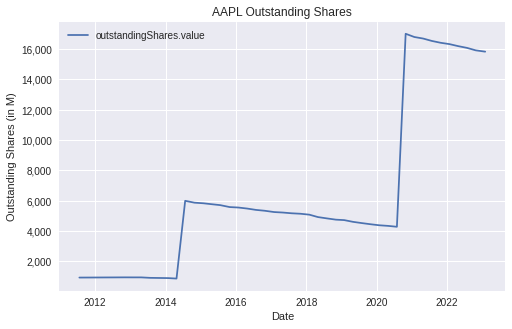

In [9]:
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn')

# y-axis formatter formats "16000000000" to "16,000"
def millions_formatter(x, pos):
    return '{:,.0f}'.format(x*1e-6)

ax = aapl_float.plot(y='outstandingShares.value', x='reportedAt')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(millions_formatter))
ax.figure.autofmt_xdate(rotation=0, ha='center')
ax.set_xlabel('Date')
ax.set_ylabel('Outstanding Shares (in M)')
ax.set_title('AAPL Outstanding Shares')
plt.show()